In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## load the data

In [2]:
df = pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\NLP\\Day7\\toxic-comments.csv")

In [3]:
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [4]:
df.shape

(159571, 8)

In [5]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='str')

In [6]:
df.dtypes

id                 str
comment_text       str
toxic            int64
severe_toxic     int64
obscene          int64
threat           int64
insult           int64
identity_hate    int64
dtype: object

In [7]:
comments=df.sum(numeric_only=True)

In [8]:
comments

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [9]:
comments.sum()

np.int64(35098)

<BarContainer object of 6 artists>

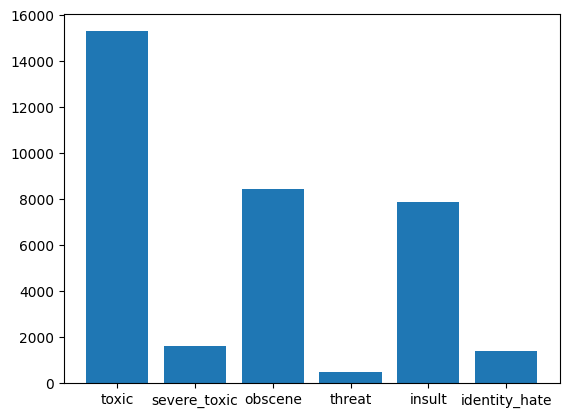

In [10]:
plt.bar(comments.index, comments)

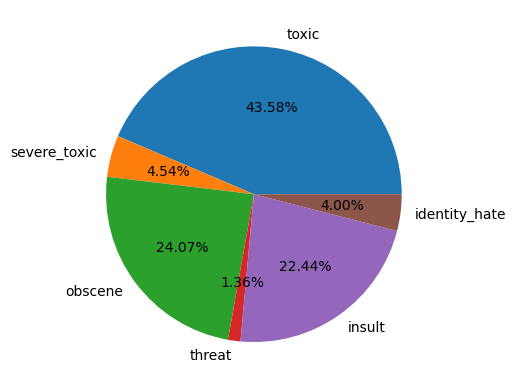

In [11]:
plt.pie(comments,labels=comments.index, autopct="%2.2f%%")
plt.show()

In [12]:
nontoxic_comments=df.sum(numeric_only=True, axis=1)

In [13]:
sum(nontoxic_comments==0)

143346

In [14]:
newdf=pd.DataFrame({
    'neutral': [sum(nontoxic_comments==0)],
    'toxic': [sum(nontoxic_comments!=0)]
})

In [15]:
newdf.T

,0
neutral,143346
toxic,16225


## Data Cleaning

In [16]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9]+',' ',text)
    return text

In [17]:
sample_text= "Hello, how are you?"

In [18]:
clean_text(sample_text)

'hello how are you '

In [19]:
## Define input variables
comments = df["comment_text"]

## define output variables
labels = df.drop(["id","comment_text"],axis = 1)

In [20]:
labels

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
159566,0,0,0,0,0,0
159567,0,0,0,0,0,0
159568,0,0,0,0,0,0
159569,0,0,0,0,0,0


In [21]:
comments_text = comments.apply(clean_text)

In [22]:
comments_text

0         explanation why the edits made under my userna...
1         d aww he matches this background colour i m se...
2         hey man i m really not trying to edit war it s...
3          more i can t make any real suggestions on imp...
4         you sir are my hero any chance you remember wh...
                                ...                        
159566     and for the second time of asking when your v...
159567    you should be ashamed of yourself that is a ho...
159568    spitzer umm theres no actual article for prost...
159569    and it looks like it was actually you who put ...
159570     and i really don t think you understand i cam...
Name: comment_text, Length: 159571, dtype: str

## Prepare the input data

In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, GRU
from sklearn.model_selection import train_test_split


In [24]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(comments_text)
sequences = tokenizer.texts_to_sequences(comments_text)
padded = pad_sequences(sequences, maxlen=200, padding='post')

In [25]:
padded



array([[ 678,   77,    1, ...,    0,    0,    0],
       [ 161,   51, 2619, ...,    0,    0,    0],
       [ 407,  417,    3, ...,    0,    0,    0],
       ...,
       [  48,  732,   25, ...,    0,    0,    0],
       [   5,   10,  568, ...,    0,    0,    0],
       [   5,    3,  137, ...,    0,    0,    0]],
      shape=(159571, 200), dtype=int32)

## Cross validation

In [26]:
x_train,x_test,y_train, y_test = train_test_split(padded, labels, random_state=0, test_size=0.2)

In [27]:
x_train.shape, y_train.shape

((127656, 200), (127656, 6))

In [28]:
x_test.shape, y_test.shape

((31915, 200), (31915, 6))

## Build the model

In [31]:
model = Sequential()

model.add(Embedding(5000, 100, input_length=200))
model.add(GRU(128))
model.add(Dense(6, activation='sigmoid'))

In [32]:
model.compile(loss="binary_crossentropy",optimizer="adam", metrics=["accuracy"])

## Train the model

In [34]:
model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 662s 165ms/step - accuracy: 0.9879 - loss: 0.0668 - val_accuracy: 0.9930 - val_loss: 0.0513
Epoch 2/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 661s 166ms/step - accuracy: 0.9817 - loss: 0.0471 - val_accuracy: 0.9828 - val_loss: 0.0500
Epoch 3/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 646s 162ms/step - accuracy: 0.9736 - loss: 0.0423 - val_accuracy: 0.9916 - val_loss: 0.0499


In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 100)            │         500,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 128)                 │          88,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,767,284 (6.74 MB)

 Trainable params: 589,094 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,178,190 (4.49 MB)

In [37]:
sample1 = "You are stupid. No one cares about your opinion, Just shut up."
sample2 = "You are waste of time. World is better without you."
sample3 = "Your life will be so beautiful with her."

In [41]:
def predict(comment):
    cleaned = clean_text(comment)
    new_seq = tokenizer.texts_to_sequences([cleaned])
    new_padded = pad_sequences(new_seq, maxlen=200)
    prediction = model.predict(new_padded, verbose=False)
    for i in range(len(prediction[0])):
        if prediction[0][i] > 0.5:
            print(toxicities[i])
    return prediction

In [42]:
toxicities=["toxic" , "severe_toxic" , "obscence" , "threat" , "insult" , "identity_hate"]

In [43]:
predict(sample1)

toxic


array([[0.5427033 , 0.03056344, 0.13068591, 0.00509937, 0.3553919 ,
        0.02552141]], dtype=float32)

In [44]:
predict(sample1)

toxic


array([[0.5427033 , 0.03056344, 0.13068591, 0.00509937, 0.3553919 ,
        0.02552141]], dtype=float32)